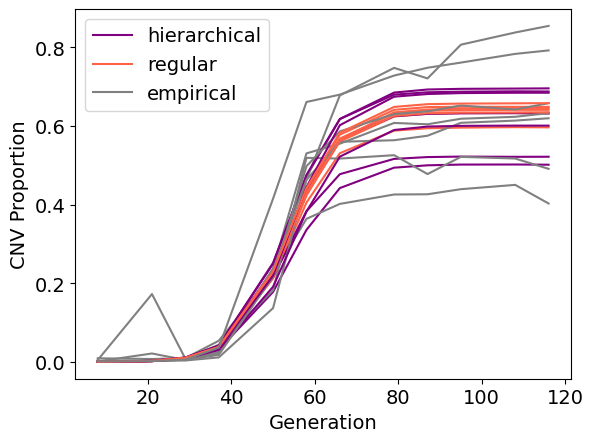

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper, wrapper_hierarchical, WF
import warnings
warnings.simplefilter('ignore', FutureWarning)

generation = np.array(pd.read_csv('empirical_data/Chuong_116_gens.txt').columns.astype('int'))

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

th = torch.tensor([-0.74,-4.84,-4.32], dtype=torch.float32)
X = wrapper(WF, parameters=th, reps=7) # LTRΔ MAP in paper
X_emp = torch.from_numpy(np.array(pd.read_csv('empirical_data/ltr.csv', index_col=0)))
X_h = wrapper_hierarchical(WF, parameters=th, reps=7)
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X_h[i], color='purple', label='hierarchical' if i==0 else '')
    plt.plot(generation,X[i], color='tomato', label='regular' if i==0 else '')
    plt.plot(generation,X_emp[i], color='grey', label='empirical' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')
plt.legend()

In [2]:
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open('posteriors/posterior_WF_30000_20.pkl', 'rb'))
Xs = torch.tensor(X_emp)
df = pd.DataFrame(index = [i for i in range(len(Xs))], columns = ['prior min', 'prior max', 'sample mean density'])
for i in range(len(Xs)):
    x = Xs[i]
    df.iloc[i,0] = round(posterior_chuong.set_default_x(x).log_prob(prior.base_dist.low).item())
    df.iloc[i,1] = round(posterior_chuong.set_default_x(x).log_prob(prior.base_dist.low).item())
    samples = posterior_chuong.sample((5000,))
    df.iloc[i,2] = round(posterior_chuong.set_default_x(x).log_prob(samples.mean(0)).item())
df

/tmp/ipykernel_19020/2416011597.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xs = torch.tensor(X_emp)


Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

,prior min,prior max,sample mean density
0,-1394,-1394,4
1,-2369,-2369,4
2,-1407,-1407,3
3,-3653,-3653,5
4,-2273,-2273,4
5,-2656,-2656,4
6,-3305,-3305,5


In [3]:
cp = CollectivePosterior(prior=prior, Xs=X_emp, amortized_posterior=posterior_chuong, epsilon=-150)
cp.get_log_C()
est = cp.sample(100).mean(0)
est, [posterior_chuong.set_default_x(Xs[i]).log_prob(est) for i in range(len(Xs))]

Rejection Sampling:   0%|          | 0/100 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/WF/../collective_posterior.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 102it [00:01, 75.99it/s]                        


(tensor([-0.6072, -5.7882, -5.2801]),
 [tensor([-0.4597]),
  tensor([3.0801]),
  tensor([-1.6389]),
  tensor([-11.2778]),
  tensor([2.1114]),
  tensor([2.1700]),
  tensor([-3.1553])])

Rejection Sampling:   0%|          | 0/20 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/WF/../collective_posterior.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 31it [00:00, 155.05it/s]                        
Rejection Sampling: 22it [00:00, 55.51it/s]                       
Rejection Sampling: 100%|██████████| 20/20 [00:00<00:00, 49.13it/s]
Rejection Sampling: 21it [00:00, 35.53it/s]                        
Rejection Sampling: 36it [00:00, 170.28it/s]                        
Rejection Sampling: 22it [00:00, 43.64it/s]                        
Rejection Sampling: 23it [00:00, 46.43it/s]                        
Rejection Sampling: 27it [00:00, 52.53it/s]                        
Rejection Sampling: 34it [00:00, 171.99it/s]         

357.9859764575958

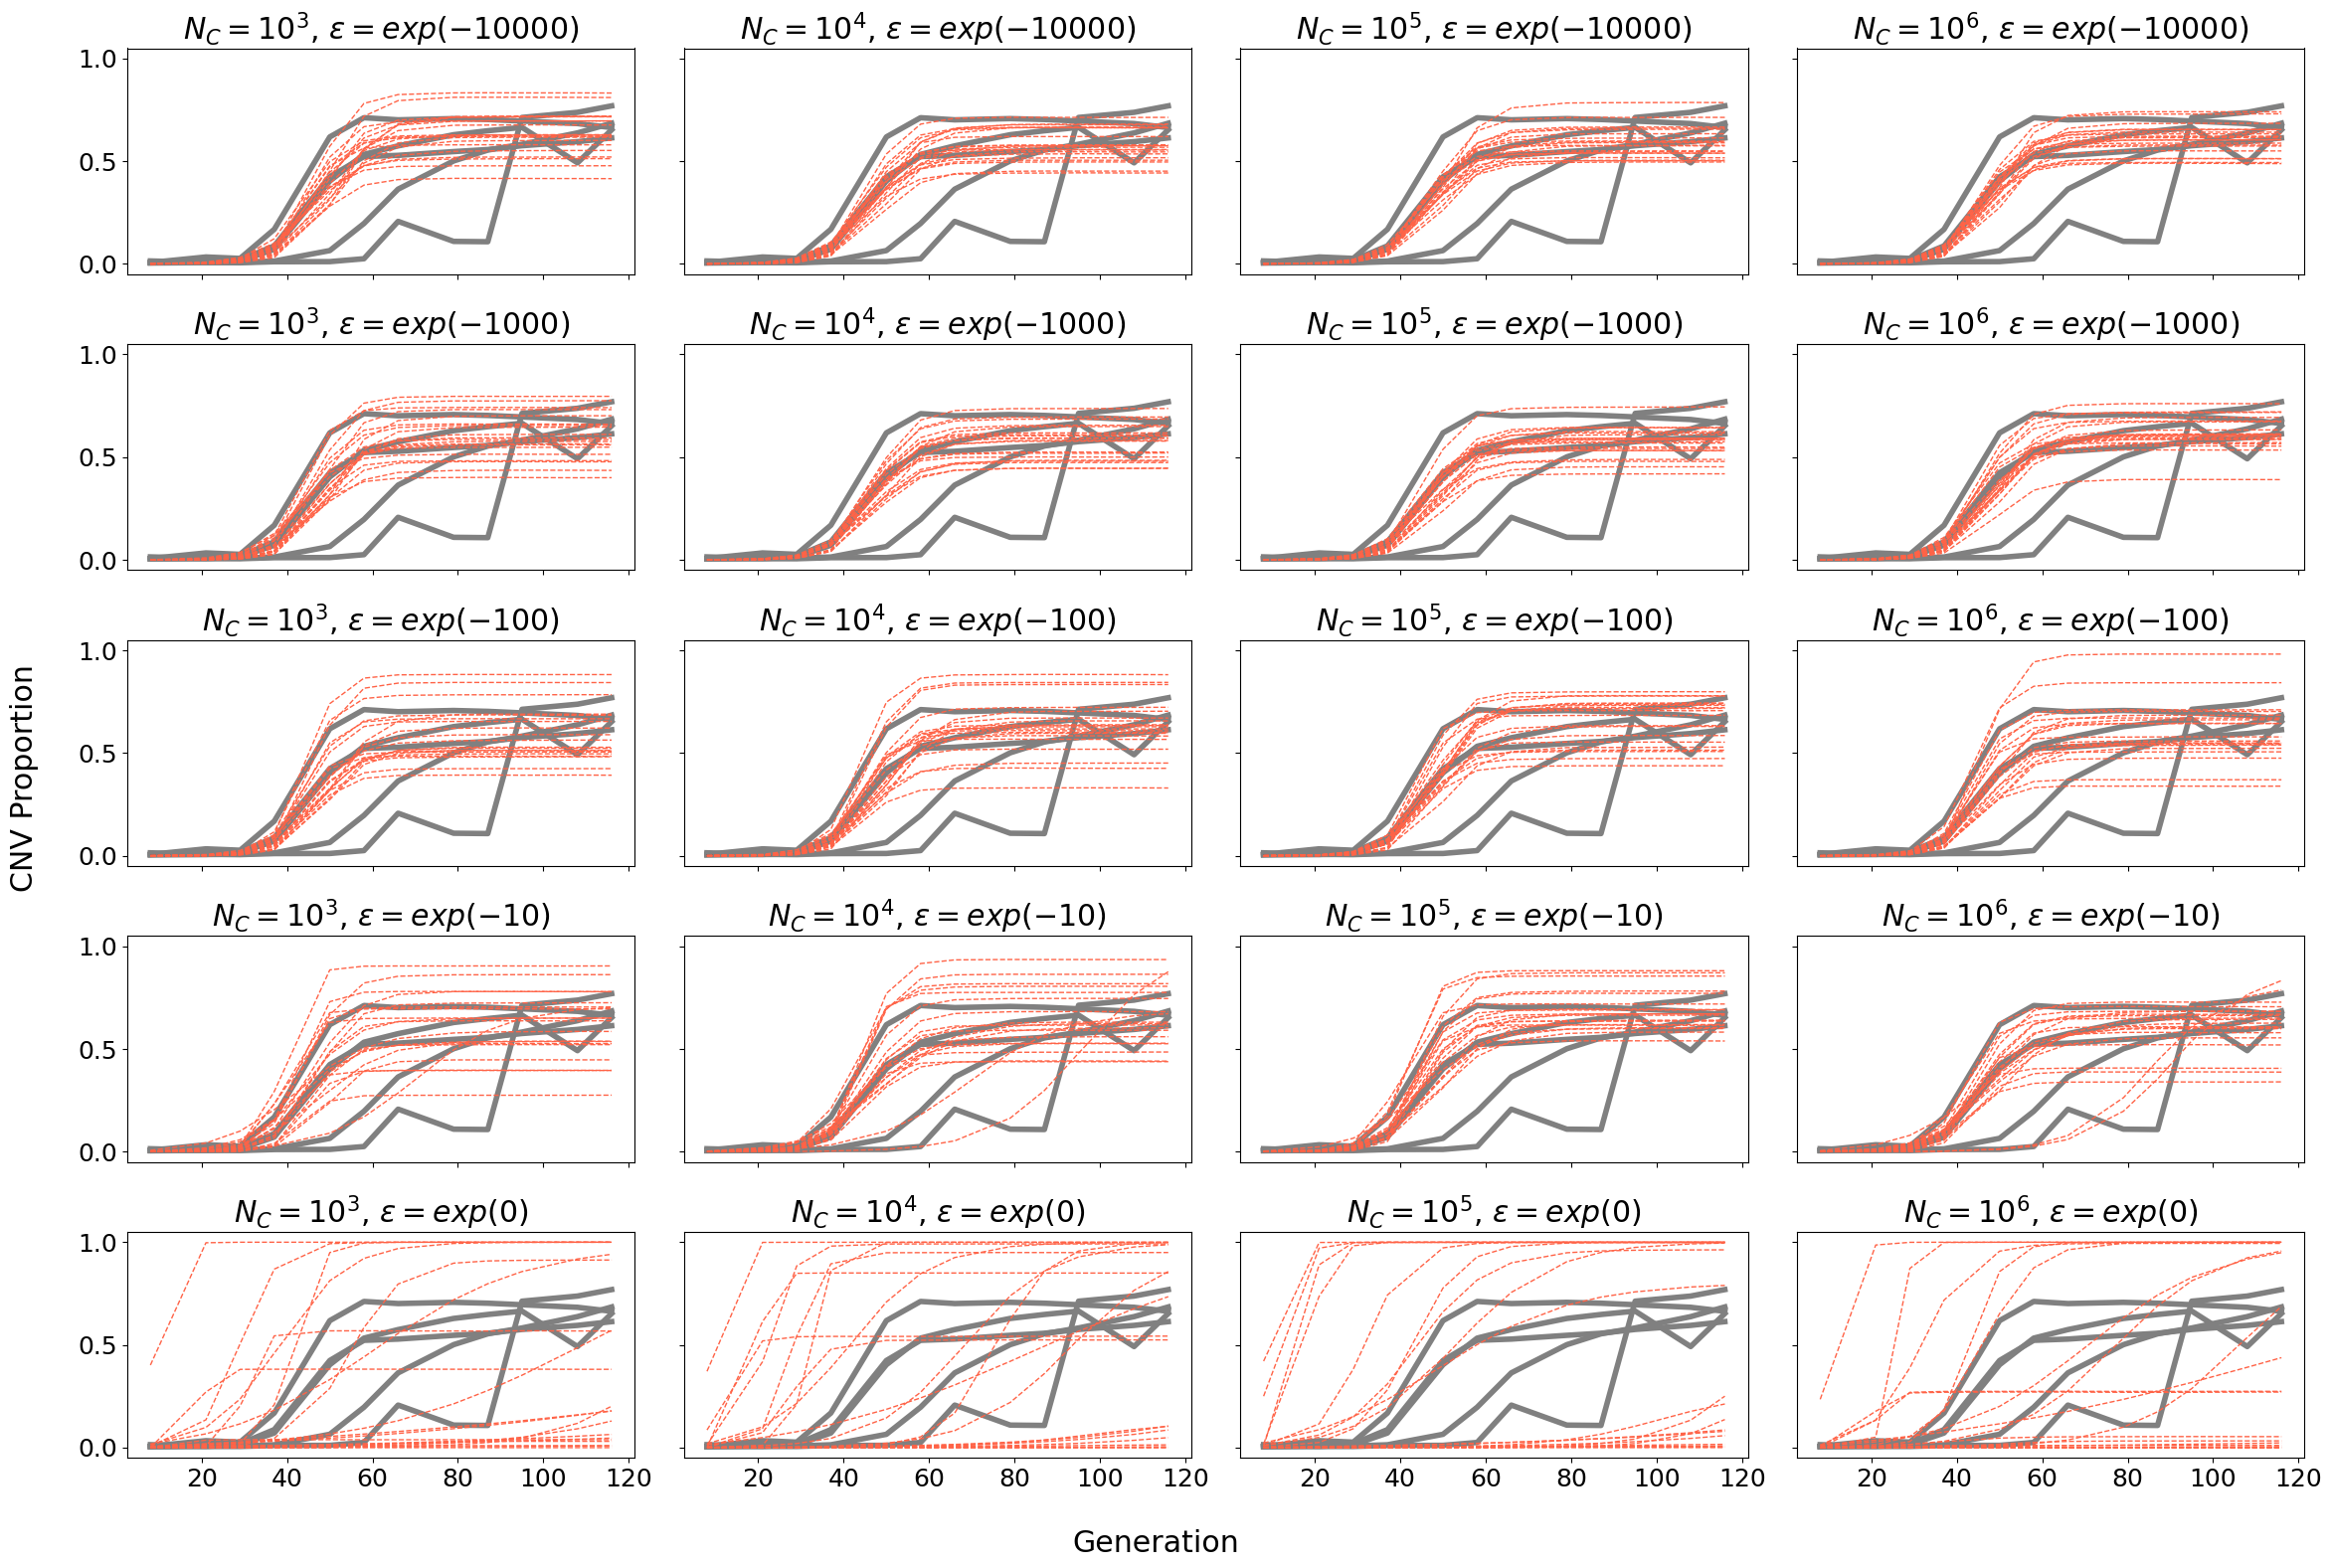

In [31]:
def plot_collective_ppc(ax, line, color, samples):
    for i in range(len(X_emp)):
        ax.plot(generation.astype('int'),X_emp[i], color='grey', lw=4, label='Empirical data' if i==0 and line=='wt' else '')
    for j in range(len(samples)):
        ax.plot(generation.astype('int'), WF(parameters=samples[j]), color=color, ls='--', lw=1, label='Collective Posterior' if j==0 and line=='wt' else '')

from time import time
t = time()
epsilons = [-10000, -1000, -100, -10, 0]
n_evals = [3,4,5,6]
change_font(18)
fig, ax = plt.subplots(len(epsilons), len(n_evals),figsize=(24,16), sharex=True, sharey=True, tight_layout=True)
fig.supylabel('CNV Proportion\n')
fig.supxlabel('Generation')
X_emp = torch.from_numpy(np.array(pd.read_csv('empirical_data/wt.csv', index_col=0)))
for i in range(len(epsilons)):
    for j in range(len(n_evals)):
        cp = CollectivePosterior(prior=prior, Xs=X_emp, amortized_posterior=posterior_chuong, epsilon=epsilons[i], n_eval=int(10**n_evals[j]))
        cp.get_log_C()
        samples = cp.sample(20)
        plot_collective_ppc(ax[i,j], 'ltr', 'tomato', samples)
        ax[i,j].set_title(f'$N_C=10^{n_evals[j]}$, $ε=exp({epsilons[i]})$')
time()-t